# 5. Viewing geometry and utilities

The smaller helpers of the package:

- `processing.pixel_to_meter` and `processing.nadir_to_center_of_frame`: footprint and nadir pixel for a given attitude,
- `geometry.make_vza_map`: viewing zenith angles of an ideal pinhole camera,
- `io.load_instrument_temperatures`: lens and window temperatures of the camera,
- `utils`: outlier masking, timing and a dask cluster.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap

from velox_tools import campaign, geometry, io, processing, utils
from velox_tools.config import load_config

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=['#2a78d6', '#eb6834']),
})
diverging = LinearSegmentedColormap.from_list('diverging', ['#104281', '#f0efec', '#b3261e'])

## Footprint and pixel size

`pixel_to_meter` gives the ground extent of a frame across and along track. It grows linearly with height:

pixel size at 10 km: 10.1 m


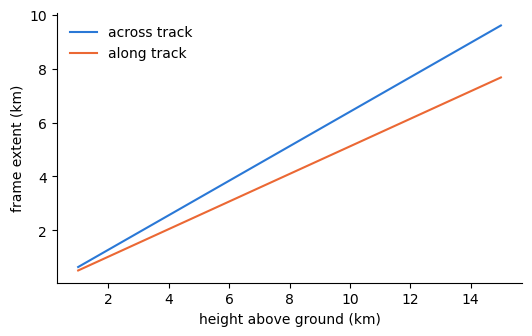

In [2]:
height = np.linspace(1000, 15000, 50)
xlen, ylen = processing.pixel_to_meter(0, 0, height)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(height / 1e3, xlen / 1e3, label='across track')
ax.plot(height / 1e3, ylen / 1e3, label='along track')
ax.set(xlabel='height above ground (km)', ylabel='frame extent (km)')
ax.legend(frameon=False)
print(f'pixel size at 10 km: {processing.pixel_to_meter(0, 0, 10000)[0] / 635:.1f} m')

`nadir_to_center_of_frame` returns the pixel that sees the ground straight below the aircraft. It moves off the frame centre when the aircraft rolls or pitches:

In [3]:
for roll, pitch in [(0, 0), (5, 0), (0, 3), (-10, 2)]:
    print(f'roll {roll:4} deg, pitch {pitch} deg -> nadir pixel {processing.nadir_to_center_of_frame(pitch, roll, 10000)}')

roll    0 deg, pitch 0 deg -> nadir pixel (317, 253)
roll    5 deg, pitch 0 deg -> nadir pixel (230, 253)
roll    0 deg, pitch 3 deg -> nadir pixel (317, 305)
roll  -10 deg, pitch 2 deg -> nadir pixel (492, 288)


## Viewing zenith angles

`make_vza_map` computes the angle between each pixel's view direction and the optical axis for an ideal pinhole camera. The calibrated angles used by `processing.project` ship with the package:

largest difference: 0.043°


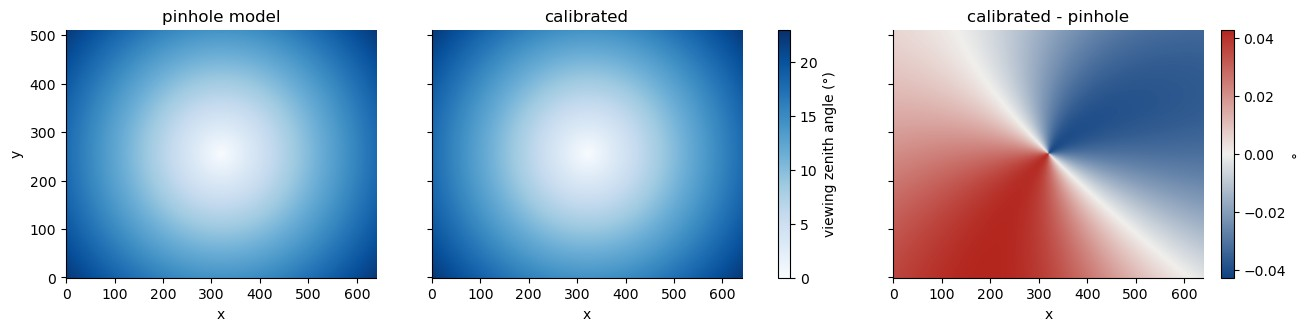

In [4]:
pinhole = geometry.make_vza_map()
calibrated = xr.open_dataset(load_config().viewing_angles)['vza']

difference = np.asarray(calibrated) - np.asarray(pinhole)
lim = np.abs(difference).max()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True, layout='constrained')
for ax, data, title in zip(axes[:2], [pinhole, calibrated], ['pinhole model', 'calibrated']):
    m = ax.imshow(np.asarray(data).T, origin='lower', cmap='Blues', vmin=0, vmax=23)
    ax.set(title=title, xlabel='x')
fig.colorbar(m, ax=axes[:2], label='viewing zenith angle (°)')
m = axes[2].imshow(difference.T, origin='lower', cmap=diverging, vmin=-lim, vmax=lim)
axes[2].set(title='calibrated - pinhole', xlabel='x')
fig.colorbar(m, ax=axes[2], label='°')
axes[0].set_ylabel('y')
print(f'largest difference: {lim:.3f}°')

## Lens and window temperatures

`load_instrument_temperatures` reads the housekeeping logs of the lens (T3) and the germanium window (T4). Without arguments it reads all HALO-(AC)3 flights; `base_glob` selects the directories, here a single flight:

In [5]:
flight_dir = os.path.join(load_config().data_root,
                          'HALO-AC3/02_Flights/HALO-AC3_20220404_HALO_RF13/VELOX/VELOX_327kveL/Processed/Additional')
T3, T4 = io.load_instrument_temperatures(flight_dir)
T3

<xarray.Dataset> Size: 49MB
Dimensions:  (time: 3052240)
Coordinates:
  * time     (time) datetime64[ns] 24MB 2022-04-04T06:52:11.100480 ... 2022-0...
Data variables:
    T3       (time) float64 24MB 26.97 26.97 26.97 26.97 ... 22.38 22.38 22.38

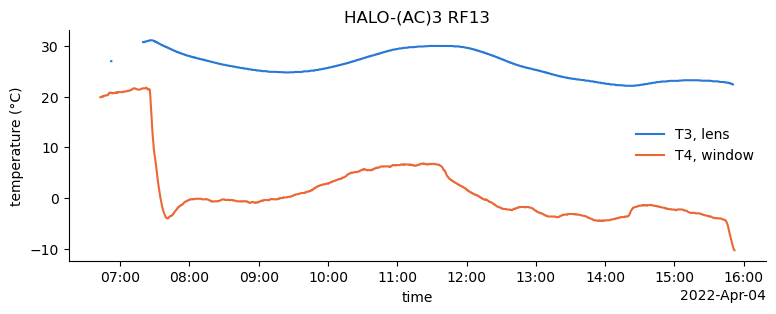

In [6]:
fig, ax = plt.subplots(figsize=(9, 3))
T3['T3'].resample(time='10s').mean().plot(ax=ax, label='T3, lens')
T4['T4'].resample(time='10s').mean().plot(ax=ax, label='T4, window')
ax.set(ylabel='temperature (°C)', title='HALO-(AC)3 RF13')
ax.legend(frameon=False);

## Utilities

`mask_percentile_outliers` sets values outside a percentile range to NaN, e.g. before computing statistics of a frame:

In [7]:
frame = campaign.load_velox(slice('2024-08-25T12:30:00', '2024-08-25T12:30:00.9'), channels=3)['BT_2D'].values.squeeze()
masked = utils.mask_percentile_outliers(frame, lo=1, hi=99)
print(f'{np.isnan(masked).sum()} of {masked.size} pixels masked, '
      f'range {np.nanmin(frame):.1f} to {np.nanmax(frame):.1f} °C -> {np.nanmin(masked):.1f} to {np.nanmax(masked):.1f} °C')

6437 of 321945 pixels masked, range -18.4 to 13.5 °C -> -12.9 to 5.0 °C


`timing_wrapper` prints the runtime of a function on every call (`processing.pushbroom` uses it):

In [8]:
@utils.timing_wrapper
def detrended_std(data):
    from velox_tools.correction import poly_detrend
    return float(np.nanstd(poly_detrend(data[None])))

detrended_std(frame)

Executed detrended_std in 0.0632 seconds


3.9122157096862793

`make_cluster` starts a local dask cluster for work on whole flights; the data from `campaign.load_velox` are dask arrays, so they are then computed in parallel. Threaded workers (`processes=False`) need no `if __name__ == '__main__'` guard in scripts:

In [9]:
client, cluster = utils.make_cluster(n_workers=4, threads_per_worker=1, memory_limit='4GB',
                                     dashboard_address=':0', processes=False)
ds = campaign.load_velox('2024-08-25', channels=3)
print(f"flight mean of BT_Center: {float(ds['BT_Center'].mean().compute()):.1f} °C")
client.close()
cluster.close()

dashboard: http://172.26.105.104:40683/status
flight mean of BT_Center: 14.9 °C
